# K-mouflage Background Solver — Examples

Comparison of power-law and arctan K-mouflage models against ΛCDM.

**Models:**
- `s_poly` : power-law $K(X) = -1 + X + K_0 X^m$, exponential coupling $\beta=0.1$
- `s_arc`  : arctan model, exponential coupling $\beta=0.1$
- `s_lcdm` : ΛCDM reference (no coupling)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from kmouflage.models.k_functions import make_powerlaw_K, make_arctan_K, make_LambdaCDM_K
from kmouflage.models.couplings   import make_exponential_coupling, make_gaussian_coupling, make_LambdaCDM_coupling
from kmouflage.solver             import KMouflageBackground, CosmologicalParams
from kmouflage.calibrate_M4       import calibrate_M4_tilde
from kmouflage.verify             import verify

## Helper: build and run a background solver

`run_background(model, coupling, potential=None, calibrate=False)` builds
and runs a `KMouflageBackground` with the shared cosmology below and
returns the live `bg` object — uncached, unlike `run_solver()` below.
`potential` is optional (`None` → `V=0`). `calibrate=True` tunes `M4_tilde`
via `calibrate_M4_tilde` instead of a plain `bg.run()` — the target is
always `1 - Ω_m0 - Ω_r0` for this cosmology, so it's a flag, not a value
(see §2 below).

In [2]:
"""
Equivalent to:
    bg = KMouflageBackground(model=model, coupling=coupling, potential=potential,
                              cosmo=CosmologicalParams(...))
    bg.run(verbose=verbose_value)
    # or, if calibrate=True, calibrate_M4_tilde(bg, target_Omega_DE=1-Omega_m0-Omega_r0, ...)
    # instead of bg.run() (calibrate_M4_tilde calls bg.run() itself, repeatedly). The target is
    # always 1 - Omega_m0 - Omega_r0 for this cosmo in practice, so it's not a free parameter here.
"""

def run_background(model, coupling, potential=None, calibrate=False,
                    verbose_value=False):  # potential=None -> no potential (V=0)
    cosmo = CosmologicalParams(H0_input=67.36, Omega_m0=0.25)
    bg = KMouflageBackground(
        model     = model,
        coupling  = coupling,
        potential = potential,
        cosmo     = cosmo,
    )
    if calibrate:
        target = 1.0 - cosmo.Omega_m0 - cosmo.Omega_r0
        calibrate_M4_tilde(bg, target_Omega_DE=target, verbose=verbose_value)
    else:
        bg.run(verbose=verbose_value)
    return bg

### `run_solver` — cached alternative

Caches results to disk (hash of the full config) and returns saved data
`{"params", "data", "run_dir"}` instead of the live `bg` object — only the
saved fields are available, not the full interpolator surface.

- `outdir=...` : where the cache lives (here, `examples/runs/` instead of
  the project-wide default).
- `fields=[...]` : extra fields to save, on top of the mandatory core.

**Minimum fields**: `N`, `a`, `phi`, `phi_prime` are always saved
(`MANDATORY_FIELDS`) — every other background quantity is a pure function
of `(phys, phi, phi_prime, a)` in `equations.py` (even `H_conf`, via
`eq.E_conf_from_F1`), so this is enough to reconstruct anything later.
`fields` isn't part of the cache key, so it has no effect on a cache hit
(`overwrite=True` forces a re-save).

In [3]:
from kmouflage import run_solver

# DEFAULT_FIELDS (kmouflage/io_utils.py) = ["z", "a", "phi", "phi_prime", "t_cosmic", "eta",
#                                            "t_superconform", "H", "H_conf", "Omega_m", "Omega_r",
#                                            "Omega_de_def", "w_de_def", "w_phi"]

cached = run_solver(
    make_powerlaw_K(K0=1, m=3),
    make_exponential_coupling(beta=0.1),
    potential=None,     # optional, None -> no potential (V=0), same as run_background
    calibrate=False,    # True -> tune M4_tilde so Omega_DE(0) = 1 - Omega_m0 - Omega_r0
    cosmo=CosmologicalParams(H0_input=67.36, Omega_m0=0.25),
    outdir="runs",  # -> examples/runs/, not the project-wide default
    fields=["z", "a", "phi", "phi_prime", "H", "Omega_m", "Omega_de_def"],  # trimmed, but keeps phi/phi_prime
)

print(cached["run_dir"])
print(sorted(cached["data"].keys()))

[run_solver] cache miss (key=d5156d6fc824) -> running

[RUN] z_ini=1.0e+05 | Omega_m=0.25 | Omega_r=8.4e-05
[OK] φ̃(z=0)=-4.3334e-01 | M_Pl0_eff=1.044287 | delta_Mpl=+4.4287e-02 | E_conf(z=0)=1.016948 | delta_H=+1.6948e-02
runs/run_0001
['H', 'N', 'Omega_de_def', 'Omega_m', 'a', 'phi', 'phi_prime', 'z']


## 1. Bare models — default M4_tilde, no potential

Each model below uses the **default** `M4_tilde = 3·(1 - Ω_m0 - Ω_r0)`,
set automatically by `CosmologicalParams.__post_init__`, and no scalar
potential. In GR this value would give exactly `Ω_DE(z=0) = 1 - Ω_m0 - Ω_r0`,
but K-mouflage's kinetic and coupling terms shift the actual `Ω_DE(z=0)`
away from that naive guess.

### 1.1 — Power-law K, exponential coupling

$K(X) = -1 + X + K_0 X^m$, $K_0=1$, $m=3$ — exponential coupling
$A(\phi) = e^{\beta\phi}$, $\beta = 0.1$.

In [4]:
s_poly = run_background(make_powerlaw_K(K0=1, m=3),
                    make_exponential_coupling(beta=0.1))
verify(s_poly)


══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : power-law (K0=1, m=3)
  Coupling: exponential (β=0.1)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +8.302e-02  [PASS]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +6.714e-03  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 9.999e-13  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.012e+00  [PASS]
  No gradient  Z > 0                      min = +1.003e+00  [PASS]
  Non-singular  |det M| > 0               min = 2.142e+00  [PASS]

  Initial conditions  (z_ini = 1.0e+05)
  ──────────────────────────────────────────────────────────────
  

False

### 1.2 — Arctan K, exponential coupling

Arctan-regularized kinetic term ($K_\star=1000$, $X_\star=100$) — same
exponential coupling, $\beta = 0.1$.

In [5]:
s_arc  = run_background(make_arctan_K(K_star=1000, X_star=100),
                    make_exponential_coupling(beta=0.1))

verify(s_arc)


══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : arctan (K_star=1000, X_star=100)
  Coupling: exponential (β=0.1)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +1.029e-01  [FAIL]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +6.560e-03  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 9.999e-13  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.014e+00  [PASS]
  No gradient  Z > 0                      min = +1.004e+00  [PASS]
  Non-singular  |det M| > 0               min = 2.143e+00  [PASS]

  Initial conditions  (z_ini = 1.0e+05)
  ──────────────────────────────────────────────────────

False

### 1.3 — ΛCDM limit ($\beta=0$)

Same power-law $K$ model, but with $\beta=0$ so $A(\phi)=1$: no coupling,
which reduces the dynamics to a ΛCDM-like background.

In [6]:
s_lcdm = run_background(make_powerlaw_K(K0=1, m=3),   # any K model if not raise and error, need to implement a specific one for ΛCDM when detect make_LambdaCDM_K or make_LambdaCDM_coupling make LambdaCDM model in solver
                    make_exponential_coupling(beta=0.0))      # A=1 → ΛCDM

verify(s_lcdm)


══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : power-law (K0=1, m=3)
  Coupling: exponential (β=0.0)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +0.000e+00  [PASS]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +0.000e+00  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 0.000e+00  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.000e+00  [PASS]
  No gradient  Z > 0                      min = +1.000e+00  [PASS]
  Non-singular  |det M| > 0               min = 2.000e+00  [PASS]

  Initial conditions  (z_ini = 1.0e+05)
  ──────────────────────────────────────────────────────────────
  

/home/tomcana/document/stage/Kmouflage_project/examples/../kmouflage/solver.py:245: RuntimeWarning: divide by zero encountered in divide
  p_de_arr / rho_de_fried_arr,  -1.0)


True

## Redshift array

All interpolators are functions of `N = ln(a)`.  
We build a common redshift grid and convert.

## 2. Calibrated models — M4_tilde tuned so Ω_DE(z=0) = target

`calibrate_M4_tilde` adjusts `M4_tilde` in place, iterating `bg.run()` until
`Ω_DE(z=0)` (the full K-mouflage definition, `Omega_de_def`) matches a
target value. Here the target is the same `1 - Ω_m0 - Ω_r0` that the
*default* `M4_tilde` targets under the GR approximation — comparing bare vs.
calibrated `M4_tilde` and `Ω_DE(0)` shows exactly how much each model's
K-mouflage dynamics shifts the energy budget away from that naive guess.

In [7]:
TARGET_ODE = 1.0 - CosmologicalParams().Omega_m0 - CosmologicalParams().Omega_r0

s_poly_cal = run_background(make_powerlaw_K(K0=1, m=3), make_exponential_coupling(beta=0.1), calibrate=True)
s_arc_cal  = run_background(make_arctan_K(K_star=1000, X_star=100), make_exponential_coupling(beta=0.1), calibrate=True)
s_lcdm_cal = run_background(make_powerlaw_K(K0=1, m=3), make_exponential_coupling(beta=0.0), calibrate=True)

print(f"target Ω_DE(0) = {TARGET_ODE:.6f}\n")
print(f"{'model':<12} {'M4_tilde (bare)':>16} {'M4_tilde (cal)':>16} {'Ω_DE(0) bare':>14} {'Ω_DE(0) cal':>14}")
for name, bare, cal in [("power-law", s_poly, s_poly_cal), ("arctan", s_arc, s_arc_cal), ("ΛCDM (β=0)", s_lcdm, s_lcdm_cal)]:
    print(f"{name:<12} {bare.M4_tilde:>16.6f} {cal.M4_tilde:>16.6f} "
          f"{float(bare.Omega_de_def(0.0)):>14.6f} {float(cal.Omega_de_def(0.0)):>14.6f}")

target Ω_DE(0) = 0.749916

model         M4_tilde (bare)   M4_tilde (cal)   Ω_DE(0) bare    Ω_DE(0) cal
power-law            2.249748         2.155664       0.758182       0.749916
arctan               2.249748         2.121775       0.761262       0.749916
ΛCDM (β=0)           2.249748         2.249748       0.749916       0.749916


In [8]:
verify(s_poly_cal)
verify(s_arc_cal)
verify(s_lcdm_cal)


══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : power-law (K0=1, m=3)
  Coupling: exponential (β=0.1)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +8.285e-02  [PASS]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +6.774e-03  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 9.999e-13  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.012e+00  [PASS]
  No gradient  Z > 0                      min = +1.003e+00  [PASS]
  Non-singular  |det M| > 0               min = 2.142e+00  [PASS]

  Initial conditions  (z_ini = 1.0e+05)
  ──────────────────────────────────────────────────────────────
  

True

In [9]:
z   = np.linspace(0, 100, 1000)
a   = 1.0 / (1.0 + z)
N   = np.log(1.0 / (1.0 + z))
N0  = 0.0   # today

In [10]:
# Wide grid for the "all universe history" panels — log-spaced so the point
# density matches the log x-axis used below (linspace would waste almost all
# points at high z and leave low z under-resolved, looking piecewise-linear).
z_hist = np.logspace(-2, 5, 10000)
N_hist = np.log(1.0 / (1.0 + z_hist))

## 1 — Hubble rate deviation $\Delta H / H_\Lambda$


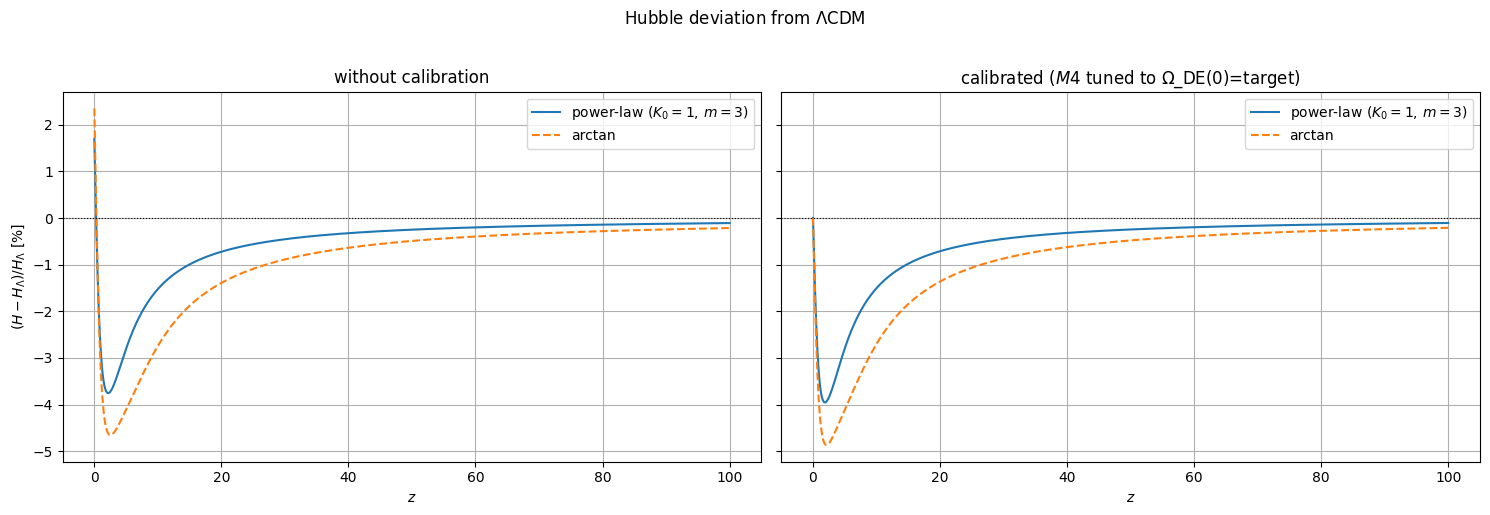

In [11]:
H0 = s_lcdm.cosmo.H0_input

H_lcdm     = s_lcdm.E_conf(N)     * (1.0 + z) * H0
H_poly     = s_poly.E_conf(N)     * (1.0 + z) * H0
H_arc      = s_arc.E_conf(N)      * (1.0 + z) * H0
H_lcdm_cal = s_lcdm_cal.E_conf(N) * (1.0 + z) * H0
H_poly_cal = s_poly_cal.E_conf(N) * (1.0 + z) * H0
H_arc_cal  = s_arc_cal.E_conf(N)  * (1.0 + z) * H0

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax = axes[0]
ax.plot(z, (H_poly - H_lcdm) / H_lcdm * 100, label=r"power-law ($K_0=1,\,m=3$)")
ax.plot(z, (H_arc  - H_lcdm) / H_lcdm * 100, label=r"arctan", ls="--")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(H - H_\Lambda)/H_\Lambda$ [%]")
ax.set_title("without calibration")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(z, (H_poly_cal - H_lcdm_cal) / H_lcdm_cal * 100, label=r"power-law ($K_0=1,\,m=3$)")
ax.plot(z, (H_arc_cal  - H_lcdm_cal) / H_lcdm_cal * 100, label=r"arctan", ls="--")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_title("calibrated ($M4$ tuned to Ω_DE(0)=target)")
ax.legend()
ax.grid(True)

plt.suptitle(r"Hubble deviation from $\Lambda$CDM", y=1.02)
plt.tight_layout()
plt.show()

## 2 — Density parameters $\Omega_i(z)$

### 2.1 All univers history


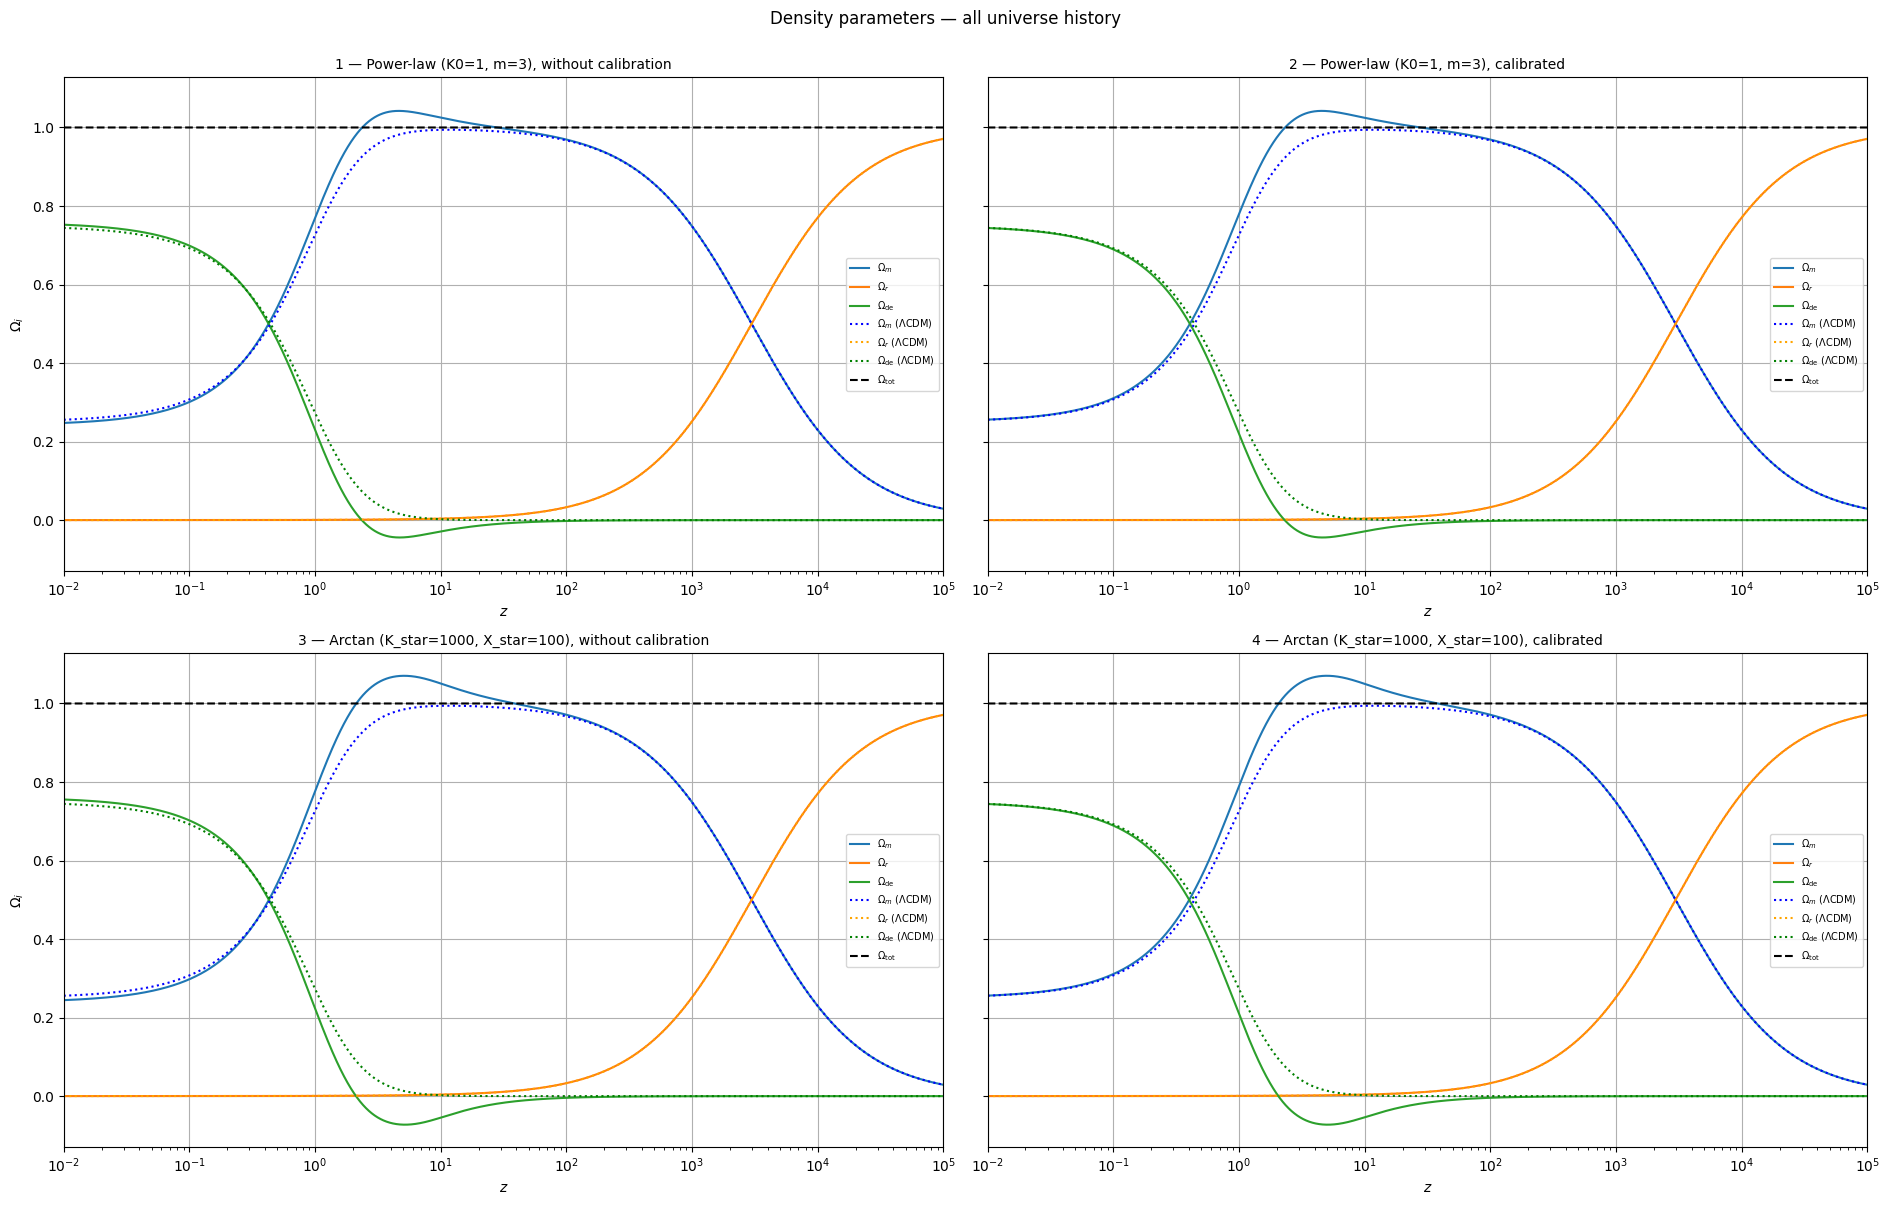

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(19, 12), sharey=True)

panels = [
    (axes[0, 0], s_poly,     s_lcdm,     "1 — Power-law (K0=1, m=3), without calibration"),
    (axes[0, 1], s_poly_cal, s_lcdm_cal, "2 — Power-law (K0=1, m=3), calibrated"),
    (axes[1, 0], s_arc,      s_lcdm,     "3 — Arctan (K_star=1000, X_star=100), without calibration"),
    (axes[1, 1], s_arc_cal,  s_lcdm_cal, "4 — Arctan (K_star=1000, X_star=100), calibrated"),
]

for ax, s, ref, title in panels:
    ax.plot(z_hist, s.Omega_m(N_hist),        label=r"$\Omega_m$")
    ax.plot(z_hist, s.Omega_r(N_hist),        label=r"$\Omega_r$")
    ax.plot(z_hist, s.Omega_de_def(N_hist),   label=r"$\Omega_{\rm de}$")

    ax.plot(z_hist, ref.Omega_m(N_hist),      label=r"$\Omega_m$ (ΛCDM)", ls=":", color="blue")
    ax.plot(z_hist, ref.Omega_r(N_hist),      label=r"$\Omega_r$ (ΛCDM)", ls=":", color="orange")
    ax.plot(z_hist, ref.Omega_de_def(N_hist), label=r"$\Omega_{\rm de}$ (ΛCDM)", ls=":", color="green")

    omega_sum = s.Omega_m(N_hist) + s.Omega_r(N_hist) + s.Omega_de_def(N_hist)
    ax.plot(z_hist, omega_sum, label=r"$\Omega_{\rm tot}$", ls="--", color="black", lw=1.5)

    ax.set_xscale("log")
    ax.set_xlim(1e-2, 1e5)
    ax.set_xlabel(r"$z$")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True)

axes[0, 0].set_ylabel(r"$\Omega_i$")
axes[1, 0].set_ylabel(r"$\Omega_i$")
plt.suptitle("Density parameters — all universe history", y=1.0)
plt.tight_layout()
plt.show()

### 2.2 Focus today

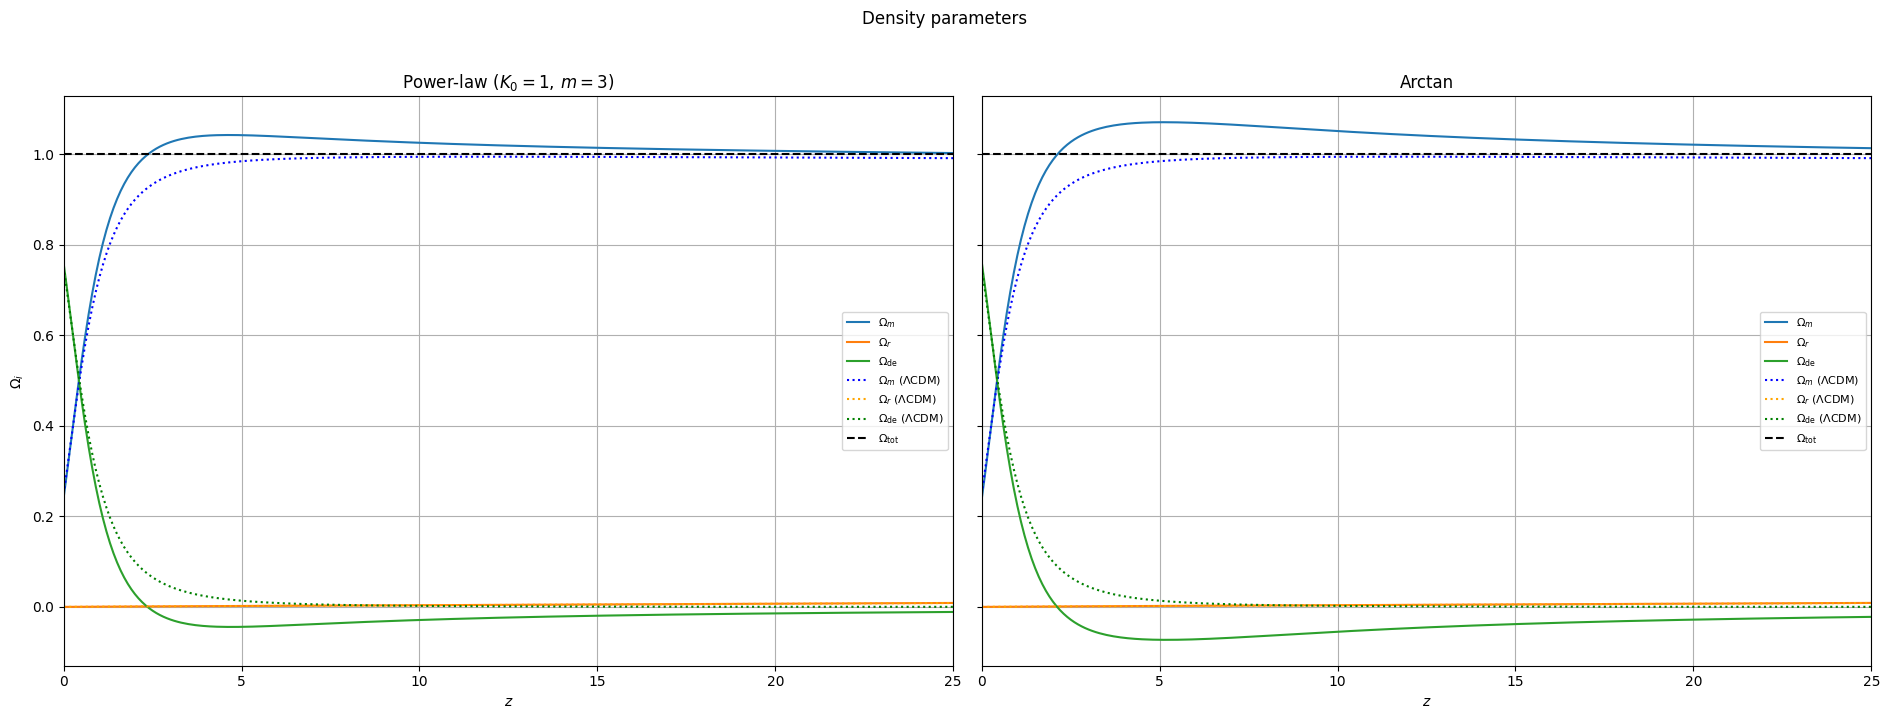

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7), sharey=True)
solvers = [s_poly, s_arc]
titles  = [r"Power-law ($K_0=1,\,m=3$)", "Arctan"]

z_mask = 25 # to see most of the effect on Omega_m and Omega_DE

for ax, s, title in zip(axes, solvers, titles):
    ax.plot(z, s.Omega_m(N),        label=r"$\Omega_m$")
    ax.plot(z, s.Omega_r(N),        label=r"$\Omega_r$")
    ax.plot(z, s.Omega_de_def(N),   label=r"$\Omega_{\rm de}$")

    ax.plot(z, s_lcdm.Omega_m(N),        label=r"$\Omega_m$ (ΛCDM)", ls=":", color="blue")
    ax.plot(z, s_lcdm.Omega_r(N),        label=r"$\Omega_r$ (ΛCDM)", ls=":", color="orange")
    ax.plot(z, s_lcdm.Omega_de_def(N),   label=r"$\Omega_{\rm de}$ (ΛCDM)", ls=":", color="green")

    omega_sum = s.Omega_m(N) + s.Omega_r(N) + s.Omega_de_def(N)
    ax.plot(z, omega_sum,           label=r"$\Omega_{\rm tot}$", ls="--",color="black", lw=1.5)
    ax.set_xlabel(r"$z$")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, z_mask)
    ax.grid(True)
    if z_mask > 1000:
        ax.set_xscale("log")
axes[0].set_ylabel(r"$\Omega_i$")
plt.suptitle("Density parameters", y=1.02)
plt.tight_layout()
plt.show()

## 3 — Equations of state

In [14]:
def mask_sign_change(y, ref):
    """Mask points where ref changes sign (w = p/rho diverges)."""
    sign = np.sign(ref)
    mask = (sign != np.roll(sign, 1)) | (sign != np.roll(sign, -1))
    return np.where(mask, np.nan, y)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1 — w_de
ax = axes[0]

w_de_poly     = mask_sign_change(s_poly.w_de_def(N_hist),     s_poly.rho_de_def(N_hist))
w_de_arc      = mask_sign_change(s_arc.w_de_def(N_hist),      s_arc.rho_de_def(N_hist))
w_de_poly_cal = mask_sign_change(s_poly_cal.w_de_def(N_hist), s_poly_cal.rho_de_def(N_hist))
w_de_arc_cal  = mask_sign_change(s_arc_cal.w_de_def(N_hist),  s_arc_cal.rho_de_def(N_hist))
w_de_lcdm     = s_lcdm.w_de_def(N_hist)

ax.plot(z_hist, w_de_poly,     color="C0", label="power-law")
ax.plot(z_hist, w_de_arc,      color="C1", label="arctan")
ax.plot(z_hist, w_de_poly_cal, color="C0", ls="--", label="power-law (calibrated)")
ax.plot(z_hist, w_de_arc_cal,  color="C1", ls="--", label="arctan (calibrated)")
ax.plot(z_hist, w_de_lcdm,     color="k",  ls=":",  label=r"$\Lambda$CDM")

for s, c in [(s_poly, "C0"), (s_arc, "C1"), (s_poly_cal, "C0"), (s_arc_cal, "C1")]:
    v = float(s.w_de_def(0.0))
    ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v), color="black", fontsize=8,
                arrowprops=dict(arrowstyle="->", color=c, lw=1.0))

ax.axhline(-1, color="grey", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_ylim(-1.5, 1)
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm De}$")
ax.set_title(r" Dark energy EoS $w_{\rm De}$")
ax.legend(fontsize=8)
ax.grid(True)

# 2 — w_phi
ax = axes[1]

ax.plot(z_hist, s_poly.w_phi(N_hist),     color="C0", label="power-law")
ax.plot(z_hist, s_arc.w_phi(N_hist),      color="C1", label="arctan")
ax.plot(z_hist, s_poly_cal.w_phi(N_hist), color="C0", ls="--", label="power-law (calibrated)")
ax.plot(z_hist, s_arc_cal.w_phi(N_hist),  color="C1", ls="--", label="arctan (calibrated)")

for s, c in [(s_poly, "C0"), (s_arc, "C1"), (s_poly_cal, "C0"), (s_arc_cal, "C1")]:
    v = float(s.w_phi(0.0))
    ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v), color="black", fontsize=8,
                arrowprops=dict(arrowstyle="->", color=c, lw=1.0))

ax.axhline(-1, color="k", lw=0.8, ls=":", label=r"$w=-1$")
ax.set_xscale("log")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi$")
ax.set_title(r" Scalar field EoS $w_\phi$")
ax.legend(fontsize=8)
ax.grid(True)

plt.suptitle("Equations of state — all universe history (solid = bare, dashed = calibrated)", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Focus late univers


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1 — w_de
ax = axes[0]

w_de_poly     = mask_sign_change(s_poly.w_de_def(N_hist),     s_poly.rho_de_def(N_hist))
w_de_arc      = mask_sign_change(s_arc.w_de_def(N_hist),      s_arc.rho_de_def(N_hist))
w_de_poly_cal = mask_sign_change(s_poly_cal.w_de_def(N_hist), s_poly_cal.rho_de_def(N_hist))
w_de_arc_cal  = mask_sign_change(s_arc_cal.w_de_def(N_hist),  s_arc_cal.rho_de_def(N_hist))
w_de_lcdm     = s_lcdm.w_de_def(N_hist)

ax.plot(z_hist, w_de_poly,     color="C0", label="power-law")
ax.plot(z_hist, w_de_arc,      color="C1", label="arctan")
ax.plot(z_hist, w_de_poly_cal, color="C0", ls="--", label="power-law (calibrated)")
ax.plot(z_hist, w_de_arc_cal,  color="C1", ls="--", label="arctan (calibrated)")
ax.plot(z_hist, w_de_lcdm,     color="k",  ls=":",  label=r"$\Lambda$CDM")



ax.axhline(-1, color="grey", lw=0.8, ls=":")
ax.set_xlim(0,10)
ax.set_ylim(-1.5, 1)
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm De}$")
ax.set_title(r" Dark energy EoS $w_{\rm De}$")
ax.legend(fontsize=8)
ax.grid(True)

# 2 — w_phi
ax = axes[1]

ax.plot(z_hist, s_poly.w_phi(N_hist),     color="C0", label="power-law")
ax.plot(z_hist, s_arc.w_phi(N_hist),      color="C1", label="arctan")
ax.plot(z_hist, s_poly_cal.w_phi(N_hist), color="C0", ls="--", label="power-law (calibrated)")
ax.plot(z_hist, s_arc_cal.w_phi(N_hist),  color="C1", ls="--", label="arctan (calibrated)")


ax.axhline(-1, color="k", lw=0.8, ls=":", label=r"$w=-1$")
ax.set_xlim(0,10)
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi$")
ax.set_title(r" Scalar field EoS $w_\phi$")
ax.legend(fontsize=8)
ax.grid(True)

plt.suptitle("Equations of state  all universe history (solid = bare, dashed = calibrated)", y=1.02)
plt.tight_layout()
plt.show()

## 4 — Scalar field $\phi(z)$ and effective Planck mass $M_{\rm Pl,eff}(z)$

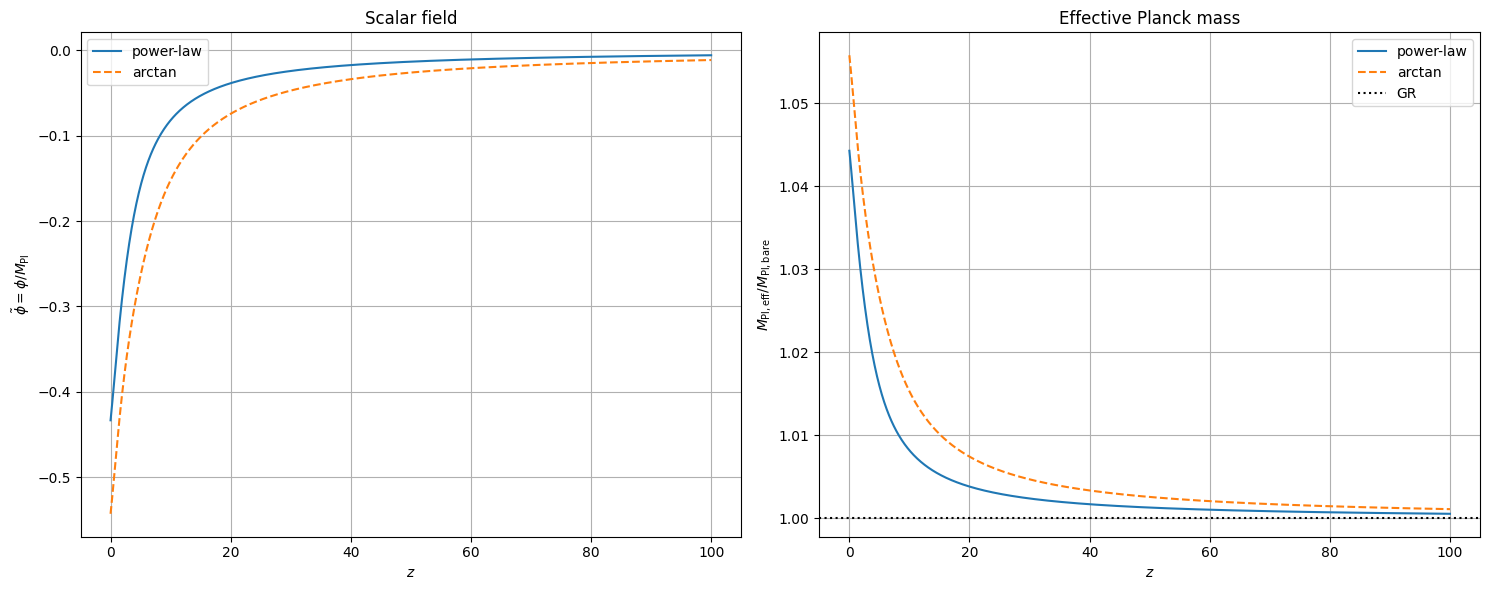

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# phi(z)  [in units of M_Pl]
ax = axes[0]
ax.plot(z, s_poly.phi(N), label="power-law")
ax.plot(z, s_arc.phi(N),  label="arctan", ls="--")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\tilde\phi = \phi/M_{\rm Pl}$")
ax.set_title("Scalar field")
ax.legend()

# M_Pl_eff(z) = sqrt(F(z))  [in units of M_Pl_bare]
ax = axes[1]
ax.plot(z, np.sqrt(s_poly.F(N)), label="power-law")
ax.plot(z, np.sqrt(s_arc.F(N)),  label="arctan", ls="--")
ax.axhline(1, color="black", lw=1.5, ls=":", label="GR")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$M_{\rm Pl,eff}/M_{\rm Pl,bare}$")
ax.set_title("Effective Planck mass")
ax.legend()

axes[0].grid(True)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5 — Newton modification $\mu_K(z)$

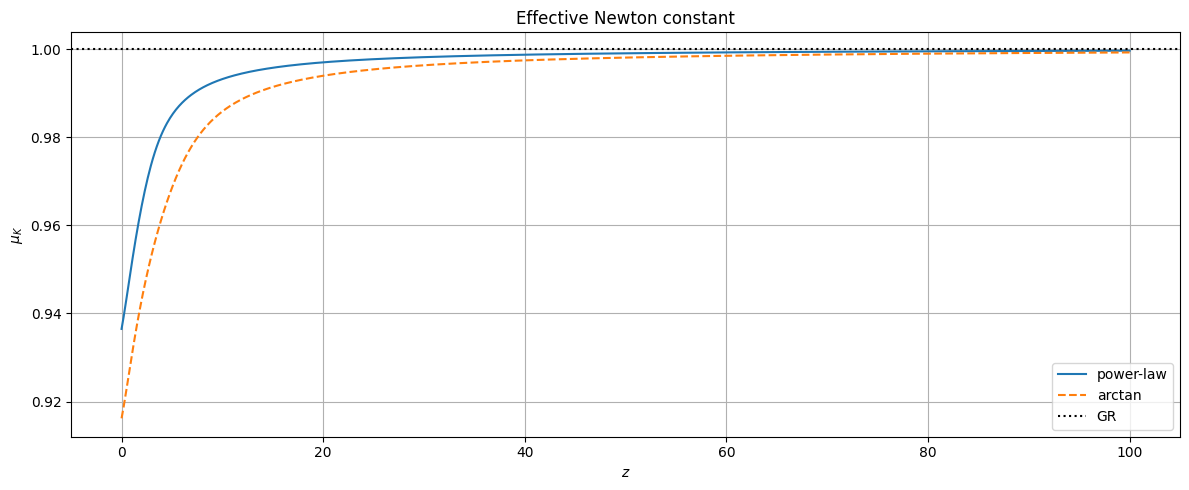

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z, s_poly.mu_K(N), label="power-law")
ax.plot(z, s_arc.mu_K(N),  label="arctan", ls="--")
ax.axhline(1, color="black", lw=1.5, ls=":", label="GR")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\mu_K$")
ax.set_title("Effective Newton constant")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6 — Physical quantities via `get_physical()`

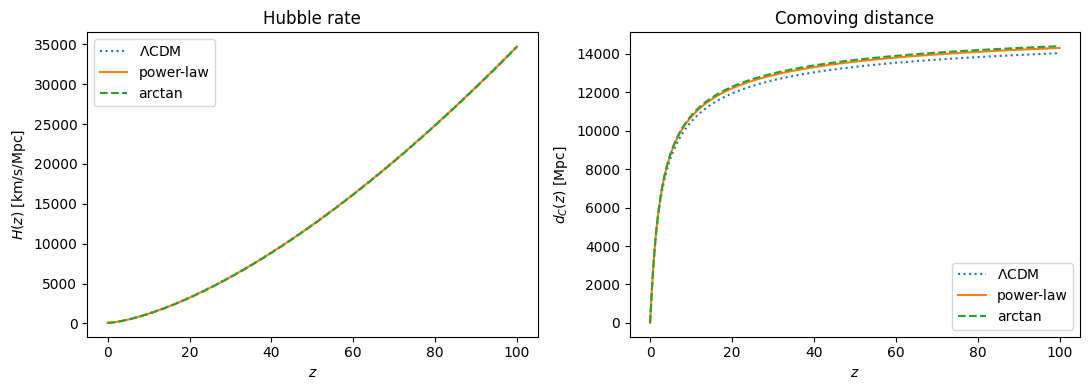

Age of the universe today:
  power-law : 14.957 Gyr
  arctan    : 15.002 Gyr
  ΛCDM      : 14.709 Gyr


In [19]:
phys_poly = s_poly.get_physical(z)
phys_arc  = s_arc.get_physical(z)
phys_lcdm = s_lcdm.get_physical(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# H(z) in km/s/Mpc
ax = axes[0]
ax.plot(z, phys_lcdm["H_phys"], label=r"$\Lambda$CDM", ls=":")
ax.plot(z, phys_poly["H_phys"], label="power-law")
ax.plot(z, phys_arc["H_phys"],  label="arctan", ls="--")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$H(z)$ [km/s/Mpc]")
ax.set_title("Hubble rate")
ax.legend()

# Comoving distance d_C(z) in Mpc
ax = axes[1]
ax.plot(z, phys_lcdm["d_C"], label=r"$\Lambda$CDM", ls=":")
ax.plot(z, phys_poly["d_C"], label="power-law")
ax.plot(z, phys_arc["d_C"],  label="arctan", ls="--")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$d_C(z)$ [Mpc]")
ax.set_title("Comoving distance")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Age of the universe today:")
print(f"  power-law : {phys_poly['t_today']:.3f} Gyr")
print(f"  arctan    : {phys_arc['t_today']:.3f} Gyr")
print(f"  ΛCDM      : {phys_lcdm['t_today']:.3f} Gyr")

## 7 — Equations of state $w_\phi$ and $w_{\rm De}$ — exponential coupling

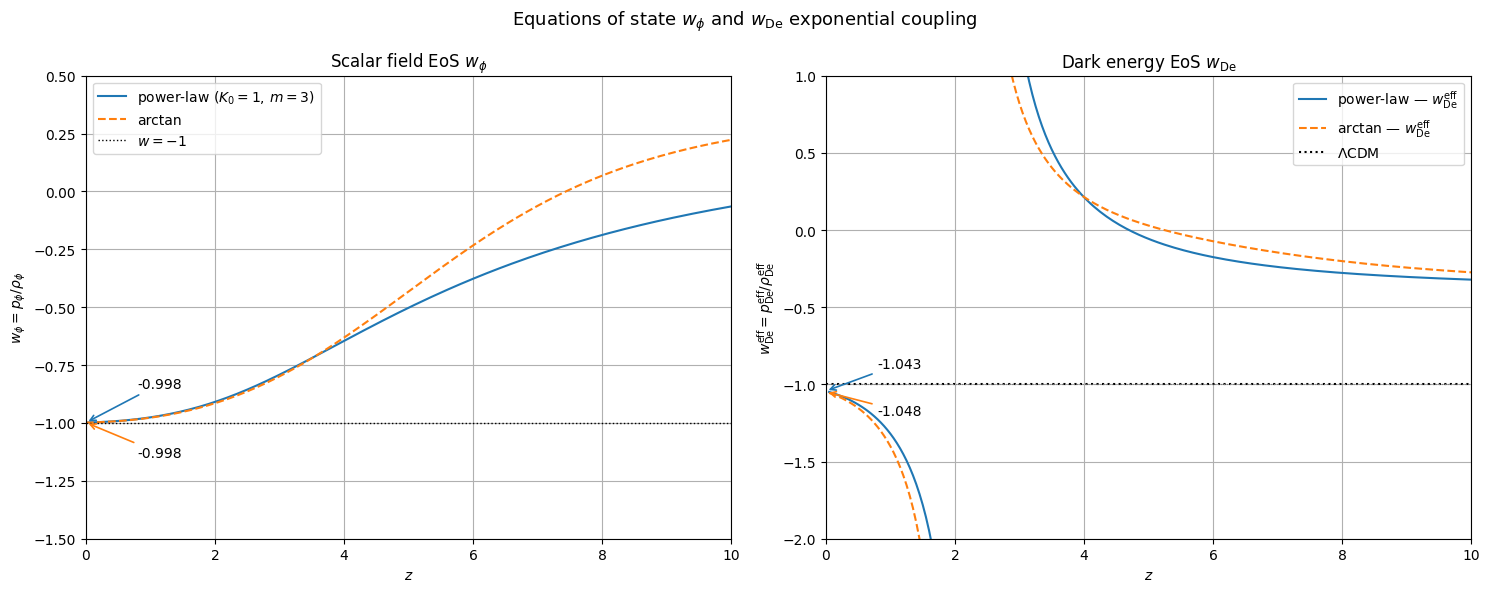

In [20]:
z_max = 1e5

z_eos = np.linspace(0, z_max, 2000000)
N_eos = np.log(1.0 / (1.0 + z_eos))

def mask_div(y, rho):
    """Mask points where rho changes sign (w = p/rho diverges)."""
    sign = np.sign(rho)
    bad  = (sign != np.roll(sign, 1)) | (sign != np.roll(sign, -1))
    return np.where(bad, np.nan, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax = axes[0]
ax.plot(z_eos, s_poly.w_phi(N_eos), label=r"power-law ($K_0=1,\,m=3$)", color="C0")
ax.plot(z_eos, s_arc.w_phi(N_eos),  label="arctan", color="C1", ls="--")
ax.axhline(-1, color="k", lw=1.0, ls=":", label=r"$w=-1$")

v = float(s_poly.w_phi(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v + 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C0", lw=1.2))
v = float(s_arc.w_phi(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v - 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C1", lw=1.2))

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi = p_\phi / \rho_\phi$")
ax.set_title(r"Scalar field EoS $w_\phi$")
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 0.5)
ax.legend()
ax.grid(True)


ax = axes[1]

w_de_poly = mask_div(s_poly.w_de_def(N_eos), s_poly.rho_de_def(N_eos))
w_de_arc  = mask_div(s_arc.w_de_def(N_eos),  s_arc.rho_de_def(N_eos))
w_de_lcdm = s_lcdm.w_de_def(N_eos)

ax.plot(z_eos, w_de_poly, label=r"power-law — $w_{\rm De}^{\rm eff}$", color="C0")
ax.plot(z_eos, w_de_arc,  label=r"arctan — $w_{\rm De}^{\rm eff}$",    color="C1", ls="--")
ax.plot(z_eos, w_de_lcdm, label=r"$\Lambda$CDM",                        color="k",  ls=":")

v = float(s_poly.w_de_def(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v + 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C0", lw=1.2))
v = float(s_arc.w_de_def(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v - 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C1", lw=1.2))

ax.axhline(-1, color="grey", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm De}^{\rm eff} = p_{\rm De}^{\rm eff} / \rho_{\rm De}^{\rm eff}$")
ax.set_title(r"Dark energy EoS $w_{\rm De}$")
ax.set_xlim(0, 10)
ax.set_ylim(-2, 1)
ax.legend()
ax.grid(True)

plt.suptitle(r"Equations of state $w_\phi$ and $w_{\rm De}$ exponential coupling", fontsize=13)
plt.tight_layout()
plt.show()

## 7 (Bis) — Equations of state $w_\phi$ and $w_{\rm De}$ — Gaussian coupling

In [21]:
s_poly_gaussian = run_background(make_powerlaw_K(K0=1, m=3), make_gaussian_coupling(beta=0.1, gamma=0.5))

s_arc_gaussian  = run_background(make_arctan_K(K_star=1000, X_star=100), make_gaussian_coupling(beta=0.1, gamma=0.5))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# w_phi
ax = axes[0]
ax.plot(z_eos, s_poly_gaussian.w_phi(N_eos), label=r"power-law ($K_0=1,\,m=3$)", color="C0")
ax.plot(z_eos, s_arc_gaussian.w_phi(N_eos),  label="arctan", color="C1", ls="--")
ax.axhline(-1, color="k", lw=1.0, ls=":", label=r"$w=-1$")

v = float(s_poly_gaussian.w_phi(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v + 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C0", lw=1.2))
v = float(s_arc_gaussian.w_phi(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v - 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C1", lw=1.2))

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi = p_\phi / \rho_\phi$")
ax.set_title(r"Scalar field EoS $w_\phi$")
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 0.5)
ax.legend()
ax.grid(True)

# w_De
ax = axes[1]

w_de_poly_g = mask_div(s_poly_gaussian.w_de_def(N_eos), s_poly_gaussian.rho_de_def(N_eos))
w_de_arc_g  = mask_div(s_arc_gaussian.w_de_def(N_eos),  s_arc_gaussian.rho_de_def(N_eos))

ax.plot(z_eos, w_de_poly_g, label=r"power-law — $w_{\rm De}^{\rm eff}$", color="C0")
ax.plot(z_eos, w_de_arc_g,  label=r"arctan — $w_{\rm De}^{\rm eff}$",    color="C1", ls="--")
ax.plot(z_eos, w_de_lcdm,   label=r"$\Lambda$CDM",                        color="k",  ls=":")

v = float(s_poly_gaussian.w_de_def(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v + 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C0", lw=1.2))
v = float(s_arc_gaussian.w_de_def(0.0))
ax.annotate(f"{v:.3f}", xy=(0, v), xytext=(0.8, v - 0.15), color="black", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="C1", lw=1.2))

ax.axhline(-1, color="grey", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm De}^{\rm eff} = p_{\rm De}^{\rm eff} / \rho_{\rm De}^{\rm eff}$")
ax.set_title(r"Dark energy EoS $w_{\rm De}^{\rm eff}$")
ax.set_xlim(0, 10)
ax.set_ylim(-2, 1)
ax.legend()
ax.grid(True)

plt.suptitle(r"Equations of state $w_\phi$ and $w_{\rm De}$  Gaussian coupling ($\beta=0.1,\,\gamma=0.5$)", fontsize=13)
plt.tight_layout()
plt.show()

## 8 — Linear growth: $D_+$ and $f\sigma_8$

`KmouflageGrowth(bg, N_points=...)` derives $\gamma(N)$/$S(N)$ from an
already-integrated `KMouflageBackground` and solves the growth ODE
$f' + f^2 + \gamma f = S$ for the growth rate $f = d\ln D_+/dN$ and the
growth factor $D_+$ (normalized to $D_+(z{=}0)=1$). `LCDMGrowth` is the
independent closed-form $\Lambda$CDM reference — it does **not** take a
`bg` (see `growth.py`'s module docstring for why: mixing K-mouflage's
numerical background into the exact $\Lambda$CDM limit would let numerical
error contaminate a closed-form result).

We plot $D_+$ on its own first, then combine it with $f$ into
$f\sigma_8(z) = f(z)\cdot\sigma_{8,0}\cdot D_+(z)$ (valid since $D_+$ is
normalized to 1 today) and compare it to the DESI DR1 BAO+RSD points.

In [25]:
from kmouflage.growth import KmouflageGrowth, LCDMGrowth

growth_poly = KmouflageGrowth(s_poly, N_points=2000).run(verbose=False)
growth_arc  = KmouflageGrowth(s_arc,  N_points=2000).run(verbose=False)
growth_lcdm = LCDMGrowth(Omega_m0=s_lcdm.cosmo.Omega_m0, Omega_r0=s_lcdm.cosmo.Omega_r0,
                          N_points=2000).run(verbose=False)

print(f"f(z=0):   power-law={growth_poly['f'][-1]:.5f}  arctan={growth_arc['f'][-1]:.5f}  "
      f"ΛCDM={growth_lcdm['f'][-1]:.5f}")
print(f"D+(z=0):  power-law={growth_poly['Dp'][-1]:.5f}  arctan={growth_arc['Dp'][-1]:.5f}  "
      f"ΛCDM={growth_lcdm['Dp'][-1]:.5f}  (normalized to 1 by construction)")

[Kmouflage] N_eq=-7.998  (z_eq=2975)
[Kmouflage] N_MDE=-2.998  (z_MDE=19, 5.0 e-folds après a_eq)
[Kmouflage] CI check à N_MDE :
             Ω_r/Ω_m = 0.0067  (attendu ≪ 1)
             μ_K     = 0.996805  (attendu ≈ 1)
             F       = 1.008134  (attendu ≈ 1)
[Kmouflage] N_eq=-7.998  (z_eq=2975)
[Kmouflage] N_MDE=-2.998  (z_MDE=19, 5.0 e-folds après a_eq)
[Kmouflage] CI check à N_MDE :
             Ω_r/Ω_m = 0.0067  (attendu ≪ 1)
             μ_K     = 0.993573  (attendu ≈ 1)
             F       = 1.015773  (attendu ≈ 1)
f(z=0):   power-law=0.44610  arctan=0.43760  ΛCDM=0.46250
D+(z=0):  power-law=1.00000  arctan=1.00000  ΛCDM=1.00000  (normalized to 1 by construction)


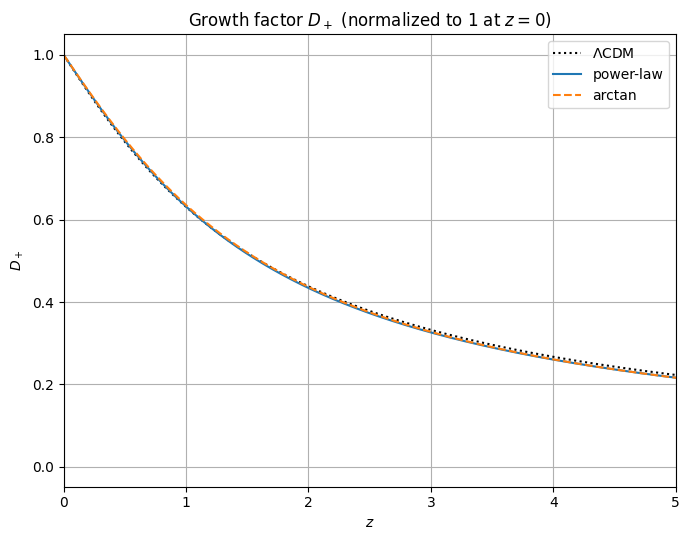

In [26]:
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.plot(growth_lcdm["z"], growth_lcdm["Dp"], color="k",  ls=":",  label=r"$\Lambda$CDM")
ax.plot(growth_poly["z"], growth_poly["Dp"], color="C0", label="power-law")
ax.plot(growth_arc["z"],  growth_arc["Dp"],  color="C1", ls="--", label="arctan")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$D_+$")
ax.set_title(r"Growth factor $D_+$ (normalized to 1 at $z=0$)")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

### 8.1 — $f\sigma_8(z)$ vs DESI DR1

$f\sigma_8(z) = f(z)\cdot\sigma_{8,0}\cdot D_+(z)$, with $\sigma_{8,0}$ the
Planck normalization and $D_+$ already normalized to 1 at $z=0$. Overlaid
against the DESI DR1 BAO+RSD $f\sigma_8$ measurements (same tracers/values
as in `comparison_potential.ipynb`).

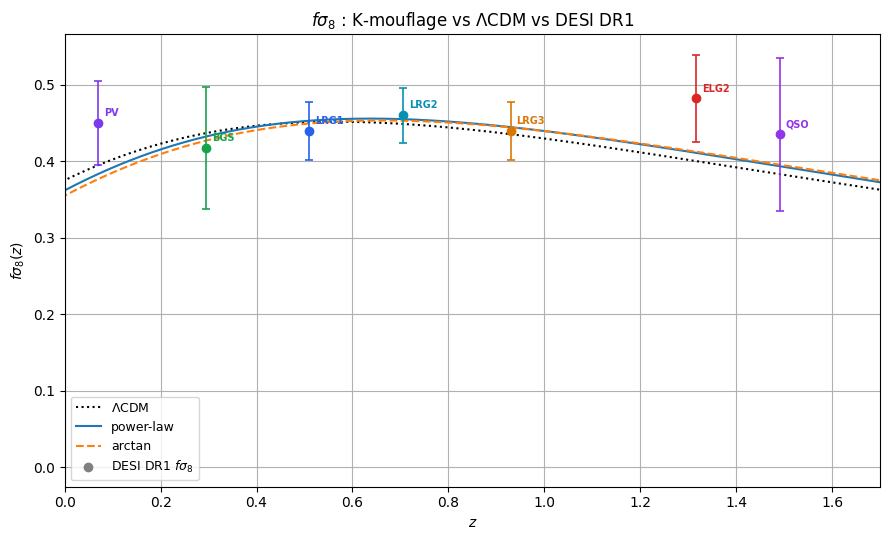

In [27]:
from matplotlib.lines import Line2D

SIGMA8_0 = 0.811   # normalisation Planck

DESI_POINTS = [
    ("PV",   0.070, 0.450, 0.055),
    ("BGS",  0.295, 0.417, 0.080),
    ("LRG1", 0.510, 0.439, 0.038),
    ("LRG2", 0.706, 0.460, 0.036),
    ("LRG3", 0.930, 0.439, 0.038),
    ("ELG2", 1.317, 0.482, 0.057),
    ("QSO",  1.491, 0.435, 0.100),
]
DESI_COLS = ["#7c3aed","#16a34a","#2563eb","#0891b2","#d97706","#dc2626","#9333ea"]

fs8_poly = growth_poly["f"] * SIGMA8_0 * growth_poly["Dp"]
fs8_arc  = growth_arc["f"]  * SIGMA8_0 * growth_arc["Dp"]
fs8_lcdm = growth_lcdm["f"] * SIGMA8_0 * growth_lcdm["Dp"]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(growth_lcdm["z"], fs8_lcdm, color="k",  ls=":",  label=r"$\Lambda$CDM")
ax.plot(growth_poly["z"], fs8_poly, color="C0", label="power-law")
ax.plot(growth_arc["z"],  fs8_arc,  color="C1", ls="--", label="arctan")

for (label, z_pt, fs8, err), col_pt in zip(DESI_POINTS, DESI_COLS):
    ax.errorbar(z_pt, fs8, yerr=err,
                fmt="o", color=col_pt, capsize=3, capthick=1.2,
                elinewidth=1.2, markersize=6, zorder=5)
    ax.annotate(label, xy=(z_pt, fs8), xytext=(4, 5),
                textcoords="offset points", fontsize=7,
                color=col_pt, fontweight="bold")

desi_handle = Line2D([0], [0], marker="o", color="gray", linestyle="None",
                      markersize=6, label=r"DESI DR1 $f\sigma_8$")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [desi_handle], fontsize=9)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$f\sigma_8(z)$")
ax.set_title(r"$f\sigma_8$ : K-mouflage vs $\Lambda$CDM vs DESI DR1")
ax.set_xlim(0, 1.7)
ax.grid(True)

plt.tight_layout()
plt.show()